In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms
 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
 
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}  [{torch.cuda.get_device_name(0) if device.type=='cuda' else 'cpu'}]")
 

device : cuda  [Tesla T4]


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp2_beta_vae"
LATENT_DIM = 16        # number of latent dimensions
EPOCHS     = 50        # training epochs
BATCH_SIZE = 256       # comfortably fits P100 VRAM
LR         = 1e-3      # adam learning rate
SNAP_EVERY = 5         # show reconstruction snapshot every N epochs
BETA       = 4.0   # try 1, 2, 4, 8 — higher = more compressed
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp2_beta_vae


In [3]:
def load_h5(path):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
ANGLES = sorted(train_angs.unique().tolist())
DIGITS = sorted(train_lbls.unique().tolist())
pin    = device.type == "cuda"
 
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs,  test_lbls,  test_angs),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)
 
print(f"train : {len(train_imgs):,}   test : {len(test_imgs):,}")
print(f"digits: {DIGITS}   angles: {ANGLES}")

  loading rotated_mnist_train.h5 ... done  (478 MB, 2.0s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.4s)
train : 152,400   test : 26,004
digits: [1, 2]   angles: [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]


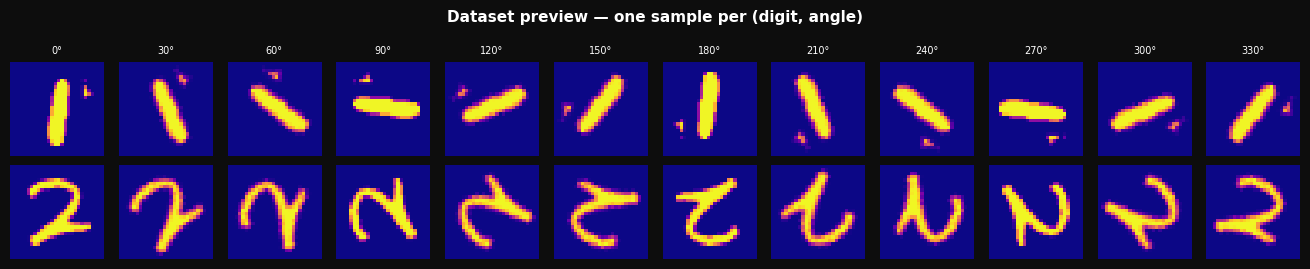

In [4]:
fig, axes = plt.subplots(len(DIGITS), len(ANGLES),
                         figsize=(len(ANGLES)*1.1, len(DIGITS)*1.4),
                         facecolor="#0d0d0d")
fig.suptitle("Dataset preview — one sample per (digit, angle)",
             color="white", fontsize=11, fontweight="bold")
 
for row, digit in enumerate(DIGITS):
    mask    = (train_lbls == digit) & (train_angs == 0)
    base    = train_imgs[mask.nonzero(as_tuple=True)[0][0]]
    for col, angle in enumerate(ANGLES):
        img = (base.squeeze().numpy() if angle == 0 else
               tvrotate(base.unsqueeze(0), float(angle),
                        interpolation=transforms.InterpolationMode.BILINEAR,
                        fill=[0.]).squeeze().numpy())
        ax = axes[row, col]
        ax.imshow(img, cmap="plasma", vmin=0, vmax=1)
        ax.axis("off")
        if row == 0: ax.set_title(f"{angle}°", color="white", fontsize=7)
        if col == 0: ax.set_ylabel(f"dig {digit}", color="white", fontsize=9, rotation=90, labelpad=5)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "00_data_preview.png"),
            dpi=120, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [5]:
class ResBlock(nn.Module):
    """residual block with groupnorm + SiLU activation"""
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.GroupNorm(g,ch), nn.SiLU(),
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.GroupNorm(g,ch),
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))   # skip connection
 
 
class Encoder(nn.Module):
    """(B,1,28,28) → μ, log σ² ∈ ℝ^latent_dim"""
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.stem  = nn.Sequential(nn.Conv2d(1,32,4,2,1,bias=False),  nn.GroupNorm(8,32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,64,4,2,1,bias=False),  nn.GroupNorm(8,64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64,128,3,2,1,bias=False), nn.GroupNorm(8,128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_lv = nn.Linear(512, latent_dim)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):   nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        return self.fc_mu(self.fc(h)), self.fc_lv(self.fc(h))
 
 
class Decoder(nn.Module):
    """z ∈ ℝ^latent_dim → (B,1,28,28)"""
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim,512), nn.SiLU(), nn.Linear(512,128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128,64,3,2,1,output_padding=1), nn.GroupNorm(8,64), nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,32,4,2,1), nn.GroupNorm(8,32), nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,1,4,2,3), nn.Sigmoid())
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d,nn.ConvTranspose2d)): nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, z):
        return self.u3(self.u2(self.u1(self.fc(z).view(-1,128,4,4))))
 
n_enc = sum(p.numel() for p in Encoder(LATENT_DIM).parameters())
n_dec = sum(p.numel() for p in Decoder(LATENT_DIM).parameters())
print(f"encoder: {n_enc:,}  decoder: {n_dec:,}  total: {n_enc+n_dec:,} params")
 

encoder: 1,560,928  decoder: 1,554,593  total: 3,115,521 params


In [6]:
class VAE(nn.Module):
    """
    β-VAE.
    Loss = BCE(x_hat, x) + β · KL[q(z|x) || N(0,I)]
 
    WARNING: val_loss is NOT comparable to Exp1 because the KL term
    is scaled by β=4. We track val_elbo (β=1) for fair comparison.
    """
    def __init__(self, latent_dim, beta):
        super().__init__()
        self.beta    = beta
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
 
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5*lv).exp() if self.training else mu
 
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu,lv)), mu, lv, mu
 
    def loss(self, x, x_hat, mu, lv):
        N     = x.size(0)
        recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / N
        kl    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / N
        return recon + self.beta * kl, recon, kl
 
 
model = VAE(LATENT_DIM, beta=BETA).to(device)
print(f"β-VAE  β={BETA}  |  params: {sum(p.numel() for p in model.parameters()):,}")
EXP_NAME = f"Exp2 β-VAE (β={BETA})"

β-VAE  β=4.0  |  params: 3,115,521


In [7]:
def show_snapshot(model, epoch, n=8):
    model.eval()
    rng_idx = torch.randperm(len(test_imgs))[:n]
    imgs    = test_imgs[rng_idx].to(device)
    with torch.no_grad():
        recon = model(imgs)[0].cpu()
    fig, axes = plt.subplots(2, n, figsize=(n*1.3, 3), facecolor="#0d0d0d")
    fig.suptitle(f"Epoch {epoch}  —  top: original  |  bottom: reconstruction",
                 color="white", fontsize=9)
    for c in range(n):
        for r, dat in enumerate([imgs[c].cpu().squeeze(), recon[c].squeeze()]):
            ax = axes[r, c]
            ax.imshow(dat.numpy(), cmap="plasma", vmin=0, vmax=1)
            ax.axis("off")
            if r == 0:
                ax.set_title(f"d{test_lbls[rng_idx[c]].item()} {test_angs[rng_idx[c]].item()}°",
                             color="white", fontsize=6)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"snap_ep{epoch:03d}.png"),
                dpi=100, bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()
    model.train()

ep   1/50  │  recon  130.27  kl  6.30  loss(β=4.0)   155.46  │  val_recon   96.35  val_elbo  104.15  ← best


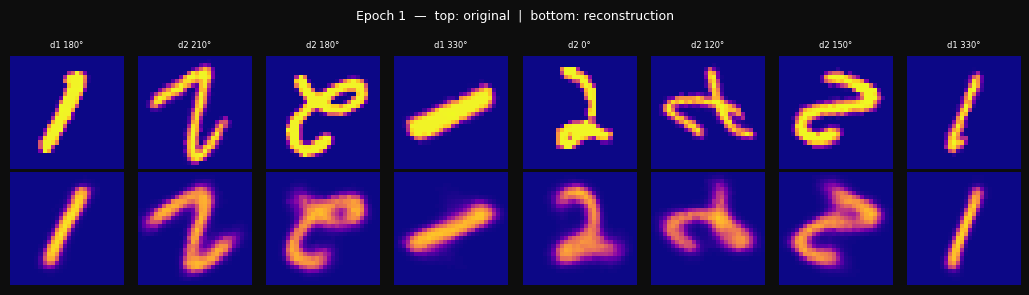

ep   2/50  │  recon  104.62  kl  7.81  loss(β=4.0)   135.86  │  val_recon   90.43  val_elbo   98.15  ← best
ep   3/50  │  recon  100.79  kl  8.06  loss(β=4.0)   133.02  │  val_recon   88.20  val_elbo   96.20  ← best
ep   4/50  │  recon   98.76  kl  8.22  loss(β=4.0)   131.65  │  val_recon   87.31  val_elbo   95.79  ← best
ep   5/50  │  recon   97.32  kl  8.33  loss(β=4.0)   130.64  │  val_recon   85.56  val_elbo   93.77  ← best


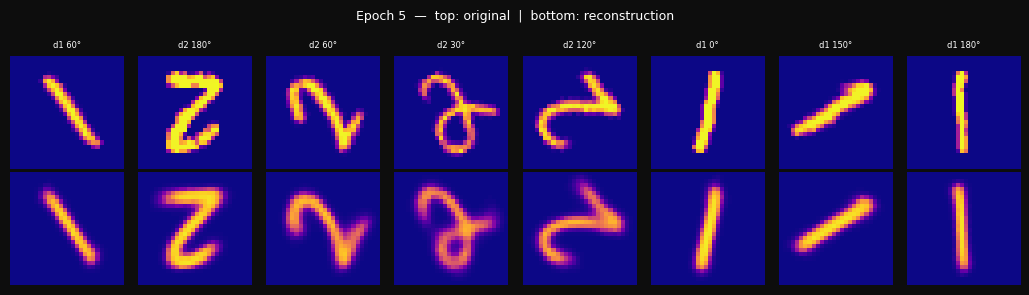

ep   6/50  │  recon   96.32  kl  8.40  loss(β=4.0)   129.94  │  val_recon   84.63  val_elbo   93.02  ← best
ep   7/50  │  recon   95.48  kl  8.46  loss(β=4.0)   129.33  │  val_recon   84.19  val_elbo   92.76  ← best
ep   8/50  │  recon   94.74  kl  8.52  loss(β=4.0)   128.83  │  val_recon   83.19  val_elbo   91.82  ← best
ep   9/50  │  recon   94.29  kl  8.56  loss(β=4.0)   128.53  │  val_recon   82.67  val_elbo   91.32  ← best
ep  10/50  │  recon   93.80  kl  8.61  loss(β=4.0)   128.23  │  val_recon   82.19  val_elbo   90.90  ← best


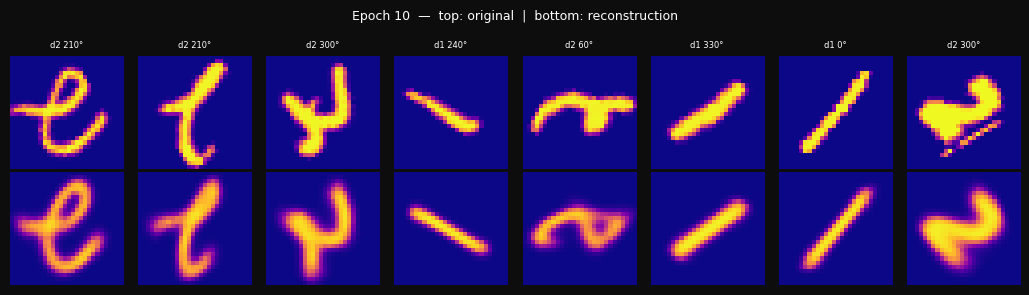

ep  11/50  │  recon   93.38  kl  8.63  loss(β=4.0)   127.91  │  val_recon   82.50  val_elbo   91.30
ep  12/50  │  recon   92.99  kl  8.66  loss(β=4.0)   127.64  │  val_recon   82.34  val_elbo   90.94
ep  13/50  │  recon   92.59  kl  8.70  loss(β=4.0)   127.39  │  val_recon   81.83  val_elbo   90.52  ← best
ep  14/50  │  recon   92.43  kl  8.71  loss(β=4.0)   127.27  │  val_recon   80.76  val_elbo   89.60  ← best
ep  15/50  │  recon   92.16  kl  8.72  loss(β=4.0)   127.05  │  val_recon   80.16  val_elbo   89.02  ← best


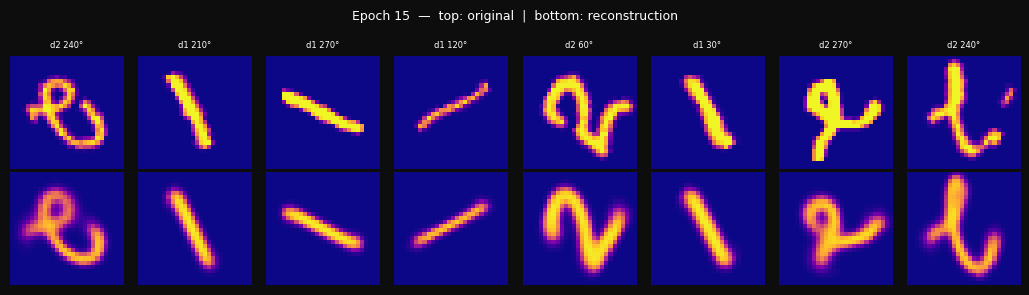

ep  16/50  │  recon   91.88  kl  8.76  loss(β=4.0)   126.94  │  val_recon   80.66  val_elbo   89.48
ep  17/50  │  recon   91.65  kl  8.77  loss(β=4.0)   126.75  │  val_recon   80.74  val_elbo   89.41
ep  18/50  │  recon   91.33  kl  8.80  loss(β=4.0)   126.51  │  val_recon   80.64  val_elbo   89.52
ep  19/50  │  recon   91.24  kl  8.80  loss(β=4.0)   126.43  │  val_recon   80.05  val_elbo   88.80  ← best
ep  20/50  │  recon   91.05  kl  8.82  loss(β=4.0)   126.32  │  val_recon   79.83  val_elbo   88.53  ← best


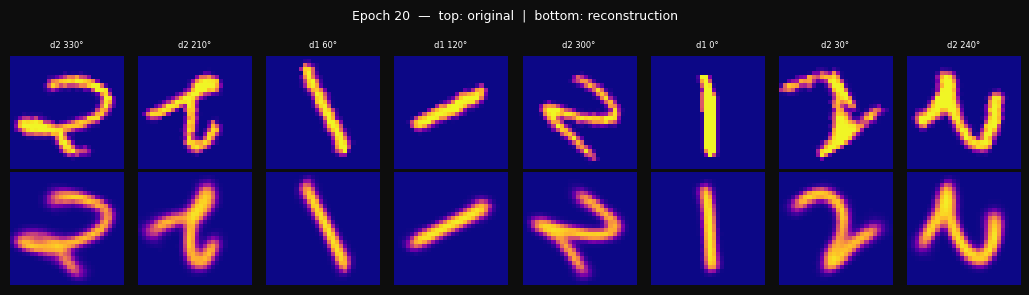

ep  21/50  │  recon   90.88  kl  8.84  loss(β=4.0)   126.22  │  val_recon   80.37  val_elbo   89.13
ep  22/50  │  recon   90.66  kl  8.85  loss(β=4.0)   126.07  │  val_recon   80.02  val_elbo   88.88
ep  23/50  │  recon   90.55  kl  8.86  loss(β=4.0)   126.01  │  val_recon   79.35  val_elbo   88.28  ← best
ep  24/50  │  recon   90.39  kl  8.87  loss(β=4.0)   125.88  │  val_recon   79.58  val_elbo   88.29
ep  25/50  │  recon   90.25  kl  8.90  loss(β=4.0)   125.83  │  val_recon   80.03  val_elbo   88.90


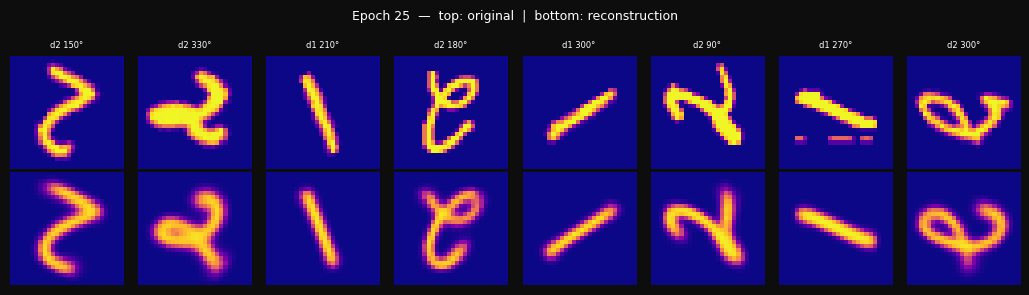

ep  26/50  │  recon   90.16  kl  8.90  loss(β=4.0)   125.74  │  val_recon   79.09  val_elbo   87.86  ← best
ep  27/50  │  recon   90.05  kl  8.90  loss(β=4.0)   125.65  │  val_recon   79.19  val_elbo   88.15
ep  28/50  │  recon   89.88  kl  8.92  loss(β=4.0)   125.55  │  val_recon   79.79  val_elbo   88.83
ep  29/50  │  recon   89.78  kl  8.92  loss(β=4.0)   125.45  │  val_recon   79.04  val_elbo   87.99
ep  30/50  │  recon   89.67  kl  8.95  loss(β=4.0)   125.45  │  val_recon   78.96  val_elbo   87.93


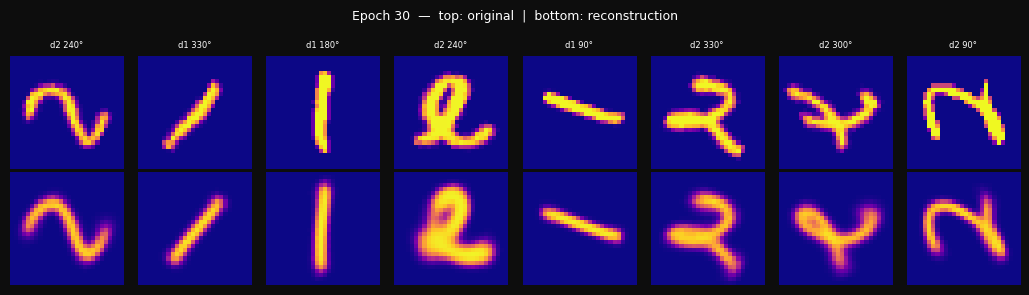

ep  31/50  │  recon   89.58  kl  8.93  loss(β=4.0)   125.31  │  val_recon   79.51  val_elbo   88.43
ep  32/50  │  recon   89.53  kl  8.94  loss(β=4.0)   125.28  │  val_recon   79.18  val_elbo   88.23
ep  33/50  │  recon   89.34  kl  8.94  loss(β=4.0)   125.09  │  val_recon   79.54  val_elbo   88.61
ep  34/50  │  recon   88.22  kl  9.02  loss(β=4.0)   124.30  │  val_recon   77.63  val_elbo   86.69  ← best
ep  35/50  │  recon   87.96  kl  9.03  loss(β=4.0)   124.07  │  val_recon   77.53  val_elbo   86.56  ← best


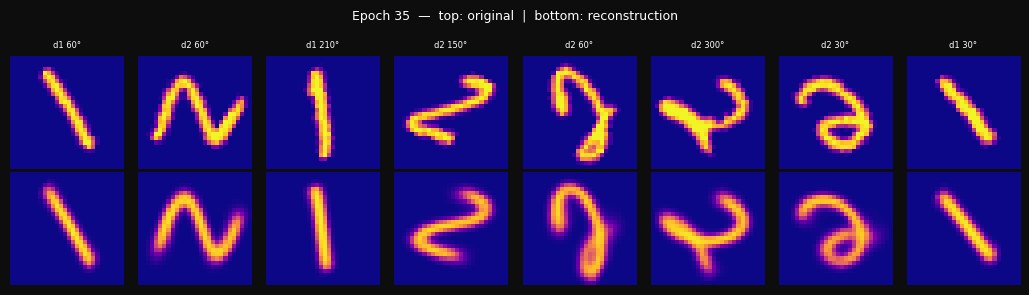

ep  36/50  │  recon   87.83  kl  9.05  loss(β=4.0)   124.03  │  val_recon   77.41  val_elbo   86.37  ← best
ep  37/50  │  recon   87.73  kl  9.06  loss(β=4.0)   123.97  │  val_recon   77.64  val_elbo   86.59
ep  38/50  │  recon   87.67  kl  9.07  loss(β=4.0)   123.95  │  val_recon   77.43  val_elbo   86.52
ep  39/50  │  recon   87.61  kl  9.07  loss(β=4.0)   123.87  │  val_recon   77.40  val_elbo   86.39
ep  40/50  │  recon   87.53  kl  9.08  loss(β=4.0)   123.84  │  val_recon   77.15  val_elbo   86.21  ← best


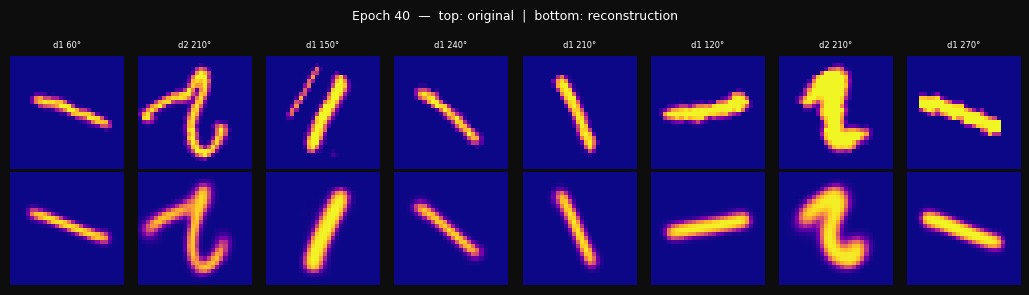

ep  41/50  │  recon   87.51  kl  9.08  loss(β=4.0)   123.83  │  val_recon   77.36  val_elbo   86.39
ep  42/50  │  recon   87.44  kl  9.08  loss(β=4.0)   123.78  │  val_recon   77.75  val_elbo   86.74
ep  43/50  │  recon   87.38  kl  9.08  loss(β=4.0)   123.71  │  val_recon   77.38  val_elbo   86.46
ep  44/50  │  recon   87.36  kl  9.10  loss(β=4.0)   123.75  │  val_recon   77.46  val_elbo   86.42
ep  45/50  │  recon   87.28  kl  9.09  loss(β=4.0)   123.65  │  val_recon   77.19  val_elbo   86.36


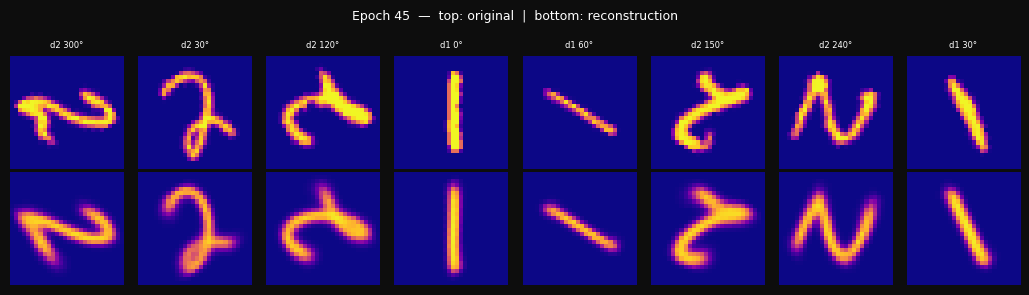

ep  46/50  │  recon   87.25  kl  9.11  loss(β=4.0)   123.69  │  val_recon   77.18  val_elbo   86.35
ep  47/50  │  recon   87.21  kl  9.11  loss(β=4.0)   123.63  │  val_recon   77.66  val_elbo   86.81
ep  48/50  │  recon   86.60  kl  9.14  loss(β=4.0)   123.17  │  val_recon   76.78  val_elbo   85.97  ← best
ep  49/50  │  recon   86.42  kl  9.15  loss(β=4.0)   123.04  │  val_recon   76.46  val_elbo   85.63  ← best
ep  50/50  │  recon   86.37  kl  9.16  loss(β=4.0)   123.03  │  val_recon   76.47  val_elbo   85.56  ← best


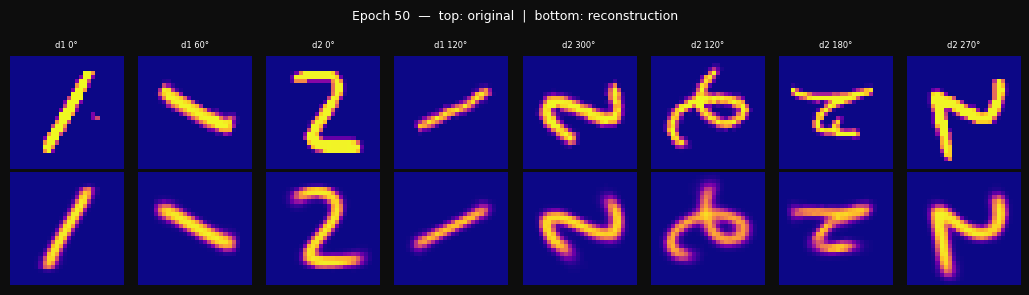


best model loaded  (epoch 50, val_elbo=85.56)


In [8]:
opt       = torch.optim.Adam(model.parameters(), lr=LR)
sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.5, patience=6)
history   = {k:[] for k in ["train_loss","train_recon","train_kl",
                             "val_loss",  "val_recon",  "val_kl",  "val_elbo"]}
snapshots = {}
best_val  = float("inf")   # tracked on val_elbo (β=1), not val_loss
 
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
 
    model.train()
    tr = {"loss":0., "recon":0., "kl":0.}
    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True); opt.zero_grad()
        x_hat, mu, lv, _ = model(imgs)
        total, recon, kl  = model.loss(imgs, x_hat, mu, lv)
        total.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.); opt.step()
        tr["loss"]+=total.item(); tr["recon"]+=recon.item(); tr["kl"]+=kl.item()
    tr = {k: v/len(train_loader) for k,v in tr.items()}
 
    model.eval()
    va = {"loss":0., "recon":0., "kl":0., "elbo":0.}
    with torch.no_grad():
        for imgs, _, _ in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            x_hat, mu, lv, _ = model(imgs)
            total, recon, kl  = model.loss(imgs, x_hat, mu, lv)
            va["loss"]+=total.item(); va["recon"]+=recon.item(); va["kl"]+=kl.item()
            va["elbo"]+=(recon + kl).item()   # β=1 ELBO — fair comparison
    va = {k: v/len(test_loader) for k,v in va.items()}
 
    sched.step(va["elbo"])   # schedule on fair ELBO, not inflated loss
    for k in tr: history[f"train_{k}"].append(tr[k])
    for k in va: history[f"val_{k}"].append(va[k])
 
    if va["elbo"] < best_val:   # save best on fair ELBO
        best_val = va["elbo"]
        torch.save({"model": model.state_dict(),
                    "cfg": {"latent_dim": LATENT_DIM, "beta": BETA},
                    "epoch": epoch, "val_elbo": best_val, "val_loss": va["loss"]},
                   os.path.join(OUT_DIR, "best_model.pt"))
 
    print(f"ep {epoch:3d}/{EPOCHS}  │  "
          f"recon {tr['recon']:7.2f}  kl {tr['kl']:5.2f}  "
          f"loss(β={BETA}) {tr['loss']:8.2f}  │  "
          f"val_recon {va['recon']:7.2f}  val_elbo {va['elbo']:7.2f}"
          + ("  ← best" if va["elbo"] == best_val else ""))
 
    if epoch % SNAP_EVERY == 0 or epoch == 1:
        show_snapshot(model, epoch)
        model.eval()
        rng_idx = torch.randperm(len(test_imgs))[:8]
        with torch.no_grad():
            si = test_imgs[rng_idx].to(device)
            sr = model(si)[0].cpu()
        snapshots[epoch] = (test_imgs[rng_idx].squeeze(1).numpy(), sr.squeeze(1).numpy())
        model.train()
 
ckpt = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
best_model = VAE(LATENT_DIM, beta=BETA).to(device)
best_model.load_state_dict(ckpt["model"]); best_model.eval()
print(f"\nbest model loaded  (epoch {ckpt['epoch']}, val_elbo={ckpt['val_elbo']:.2f})")
 

In [9]:
@torch.no_grad()
def encode_all(model):
    model.eval()
    Zs, Ls, As = [], [], []
    for imgs, lbls, angs in tqdm(test_loader, desc="encoding", leave=False):
        mu, _ = model.encoder(imgs.to(device, non_blocking=True))
        Zs.append(mu.cpu().numpy())
        Ls.append(lbls.numpy())
        As.append(angs.numpy())
    return np.concatenate(Zs), np.concatenate(Ls), np.concatenate(As)
 
Z, Ls, As = encode_all(best_model)
print(f"latent codes: {Z.shape}  |  min={Z.min():.2f}  max={Z.max():.2f}  std={Z.std():.2f}")
 

encoding:   0%|          | 0/102 [00:00<?, ?it/s]

latent codes: (26004, 16)  |  min=-3.88  max=3.48  std=0.59


In [10]:
@torch.no_grad()
def compute_rie(model, n_samples=600):
    model.eval()
    base_pool = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()
    rng       = np.random.default_rng(42)
    bidx      = rng.choice(base_pool, min(n_samples, len(base_pool)), replace=False)
    per_angle = {}
    for angle in ANGLES:
        if angle == 0:
            per_angle[0] = 0.0
            continue
        diffs = []
        for s in range(0, len(bidx), 256):
            b      = bidx[s:s+256]
            img0   = test_imgs[b].to(device)
            img_th = tvrotate(img0, float(angle),
                              interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
            mu0, _ = model.encoder(img0)
            mu_th, _ = model.encoder(img_th)
            diffs.extend((mu0 - mu_th).norm(dim=1).cpu().numpy().tolist())
        per_angle[angle] = float(np.mean(diffs))
    rie = float(np.mean([v for v in per_angle.values() if v > 0]))
    return rie, per_angle
 
 
# ── METRIC 2: Linear Probe AUC ────────────────────────────────────────────────
# Measures whether z still contains class information after invariance training.
# Catches the degenerate case: model collapses everything to one point
# (which gives RIE=0 but AUC=0.5 — it cheated).
# We want: low RIE AND high AUC together.
 
def compute_lp_auc(Z, Ls):
    n    = len(Z)
    perm = np.random.default_rng(0).permutation(n)
    sp   = int(n * 0.8)
    tr_Z, va_Z = Z[perm[:sp]], Z[perm[sp:]]
    tr_L, va_L = Ls[perm[:sp]], Ls[perm[sp:]]
    clf  = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")
    clf.fit(tr_Z, tr_L)
    prob = clf.predict_proba(va_Z)[:, 1]
    return float(roc_auc_score(va_L, prob))
 
 
# ── METRIC 3: Orbit Circularity Score (OCS) ───────────────────────────────────
# Fits a circle to each orbit {z(R_θ x)} in PCA-2D latent space.
# OCS = 1 − residual/radius.   1 = perfect circle.  0 = collapsed dot.
# Characterises the GROUP STRUCTURE of the latent space, not just invariance.
# Note: a perfectly invariant model (Exp 4) will have low OCS because all
# orbit points collapse to one point — that is expected and correct.
# An equivariant model (e2cnn) would have OCS ≈ 1.
 
def _fit_circle(pts):
    x, y = pts[:,0], pts[:,1]
    A = np.column_stack([x, y, np.ones(len(x))])
    b = -(x**2 + y**2)
    try:
        c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    except np.linalg.LinAlgError:
        return 0.0, 1.0
    cx, cy = -c[0]/2, -c[1]/2
    r      = max(np.sqrt(cx**2 + cy**2 - c[2]), 1e-6)
    resid  = np.mean(np.abs(np.sqrt((x-cx)**2 + (y-cy)**2) - r))
    return r, resid
 

In [11]:
@torch.no_grad()
def compute_ocs(model, n_orbits=50):
    model.eval()
    base_pool = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()
    bidx      = np.random.default_rng(1).choice(base_pool, min(n_orbits,len(base_pool)), replace=False)
    K   = len(ANGLES)
    lat = model.encoder.latent_dim
    all_Z = np.zeros((len(bidx), K, lat))
    for i, b in enumerate(bidx):
        base = test_imgs[b:b+1]
        for k, angle in enumerate(ANGLES):
            img = (base if angle == 0 else
                   tvrotate(base, float(angle),
                            interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.]))
            mu, _ = model.encoder(img.to(device))
            all_Z[i,k] = mu.cpu().numpy()
    pca = PCA(n_components=2)
    Z2  = pca.fit_transform(all_Z.reshape(-1,lat)).reshape(len(bidx),K,2)
    scores = []
    for i in range(len(bidx)):
        pts    = Z2[i]
        radius = np.max(np.linalg.norm(pts - pts.mean(0), axis=1))
        if radius < 1e-4:
            scores.append(0.0)   # collapsed orbit
            continue
        r, resid = _fit_circle(pts)
        scores.append(max(0.0, 1.0 - resid/radius))
    return float(np.mean(scores))

In [12]:
print("computing evaluation metrics ...")
print("(this replaces ELBO as the primary evaluation for symmetry discovery)")
print()
 
print("  metric 1: Rotation Invariance Error ...", end=" ", flush=True)
rie, rie_per_angle = compute_rie(best_model)
print(f"RIE = {rie:.4f}")
 
print("  metric 2: Linear Probe AUC ...", end=" ", flush=True)
lp_auc = compute_lp_auc(Z, Ls)
print(f"AUC = {lp_auc:.4f}")
 
print("  metric 3: Orbit Circularity Score ...", end=" ", flush=True)
ocs = compute_ocs(best_model)
print(f"OCS = {ocs:.4f}")

computing evaluation metrics ...
(this replaces ELBO as the primary evaluation for symmetry discovery)

  metric 1: Rotation Invariance Error ... RIE = 2.9607
  metric 2: Linear Probe AUC ... AUC = 0.9984
  metric 3: Orbit Circularity Score ... OCS = 0.8398


  running t-SNE ... 14s


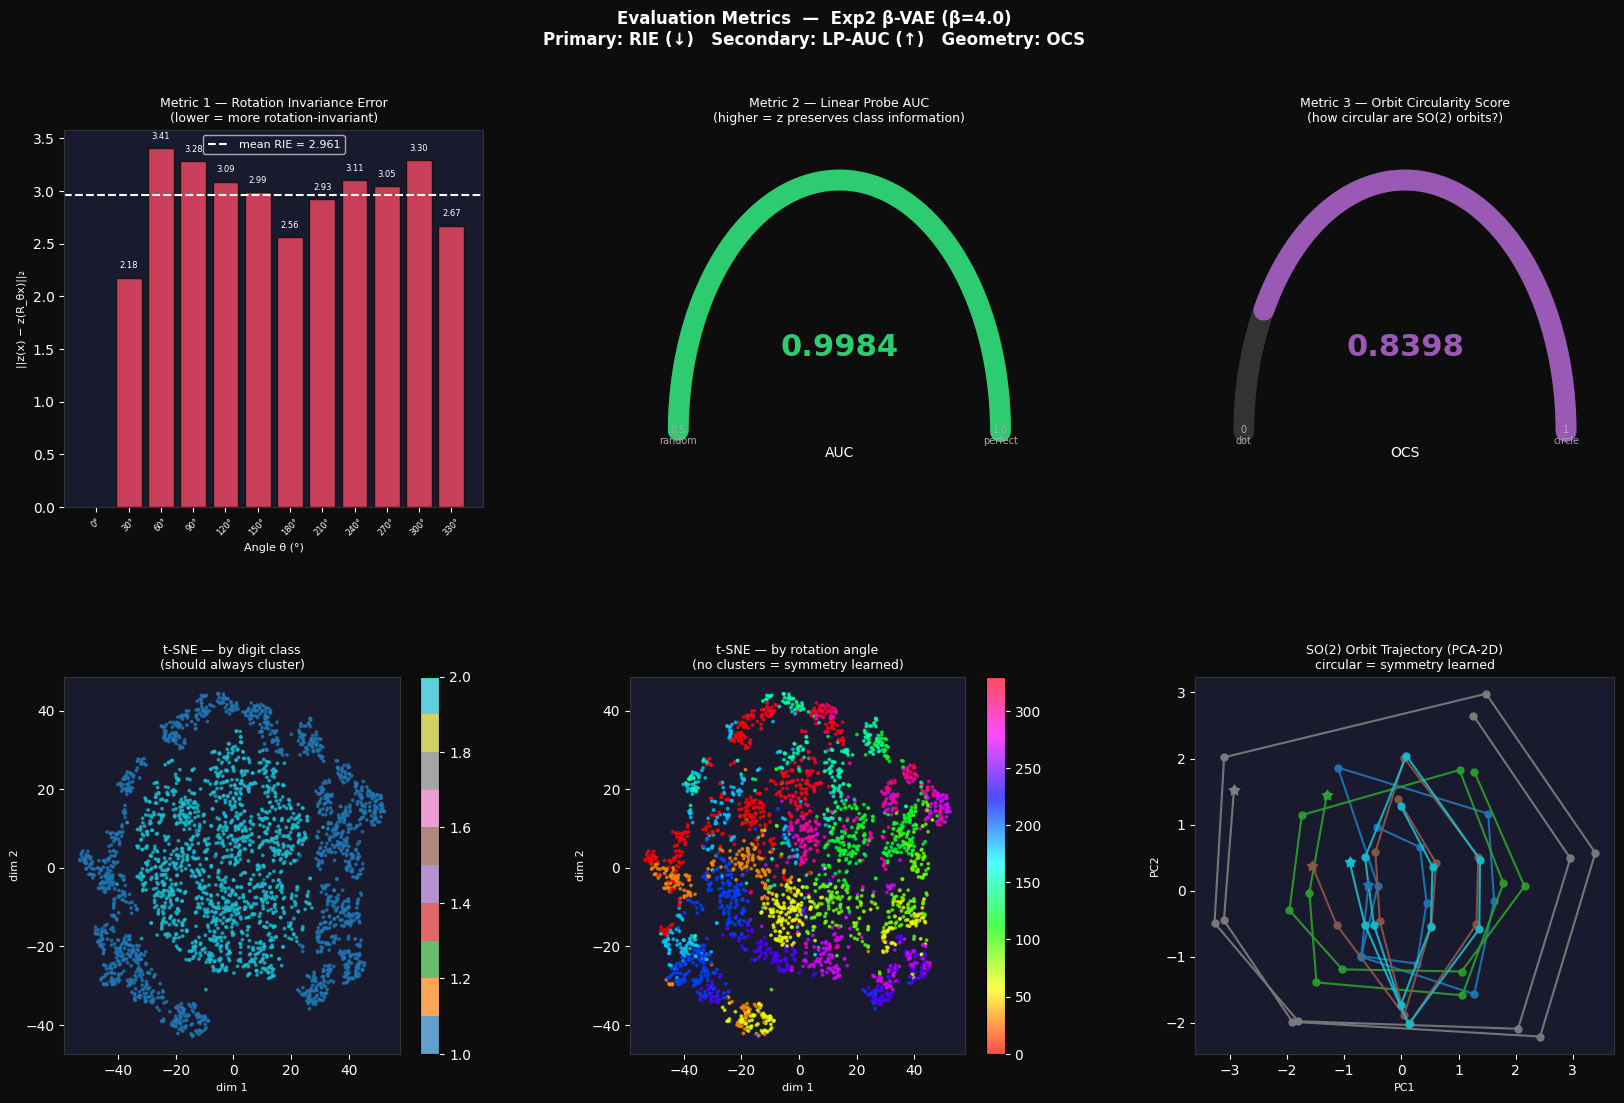

In [13]:
def _sax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#333")
    ax.set_title(title, color="white", fontsize=9)
    if xlabel: ax.set_xlabel(xlabel, color="white", fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color="white", fontsize=8)
 
fig = plt.figure(figsize=(20, 12), facecolor="#0d0d0d")
fig.suptitle(f"Evaluation Metrics  —  {EXP_NAME}\n"
             "Primary: RIE (↓)   Secondary: LP-AUC (↑)   Geometry: OCS",
             color="white", fontsize=12, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── panel 1: RIE per angle (bar) ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_sax(ax1, "Metric 1 — Rotation Invariance Error\n(lower = more rotation-invariant)",
     "Angle θ (°)", "||z(x) − z(R_θx)||₂")
ang_l = list(rie_per_angle.keys())
err_l = list(rie_per_angle.values())
bars  = ax1.bar(range(len(ang_l)), err_l, color="#e94560", alpha=0.85, edgecolor="#0d0d0d")
ax1.axhline(rie, color="white", ls="--", lw=1.5, label=f"mean RIE = {rie:.3f}")
ax1.set_xticks(range(len(ang_l)))
ax1.set_xticklabels([f"{a}°" for a in ang_l], color="white", fontsize=6, rotation=45)
ax1.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
for bar, v in zip(bars, err_l):
    if v > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, v+rie*0.03,
                 f"{v:.2f}", ha="center", color="white", fontsize=6)
 
# ── panel 2: linear probe AUC gauge ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
_sax(ax2, "Metric 2 — Linear Probe AUC\n(higher = z preserves class information)")
# draw a simple arc gauge
theta = np.linspace(0, np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), color="#333", lw=15, solid_capstyle="round")
# fill up to auc value
fill_theta = np.linspace(0, np.pi * lp_auc, 200)
color_auc  = "#2ecc71" if lp_auc > 0.9 else "#f5a623" if lp_auc > 0.75 else "#e94560"
ax2.plot(np.cos(fill_theta), np.sin(fill_theta), color=color_auc,
         lw=15, solid_capstyle="round")
ax2.text(0, 0.3, f"{lp_auc:.4f}", ha="center", color=color_auc,
         fontsize=22, fontweight="bold")
ax2.text(0, -0.1, "AUC", ha="center", color="white", fontsize=10)
ax2.text(-1.0, -0.05, "0.5\nrandom", ha="center", color="#aaa", fontsize=7)
ax2.text( 1.0, -0.05, "1.0\nperfect", ha="center", color="#aaa", fontsize=7)
ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.3, 1.2)
ax2.axis("off")
 
# ── panel 3: OCS gauge ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
_sax(ax3, "Metric 3 — Orbit Circularity Score\n(how circular are SO(2) orbits?)")
ax3.plot(np.cos(theta), np.sin(theta), color="#333", lw=15, solid_capstyle="round")
fill_ocs  = np.linspace(0, np.pi * ocs, 200)
color_ocs = "#9b59b6"
ax3.plot(np.cos(fill_ocs), np.sin(fill_ocs), color=color_ocs,
         lw=15, solid_capstyle="round")
ax3.text(0, 0.3, f"{ocs:.4f}", ha="center", color=color_ocs,
         fontsize=22, fontweight="bold")
ax3.text(0, -0.1, "OCS", ha="center", color="white", fontsize=10)
ax3.text(-1.0, -0.05, "0\ndot", ha="center", color="#aaa", fontsize=7)
ax3.text( 1.0, -0.05, "1\ncircle", ha="center", color="#aaa", fontsize=7)
ax3.set_xlim(-1.3, 1.3); ax3.set_ylim(-0.3, 1.2)
ax3.axis("off")
 
# ── panel 4: t-SNE coloured by digit and angle ───────────────────────────────
MAX_PTS = 3000
rng_tsne = np.random.default_rng(0)
idx_tsne = rng_tsne.choice(len(Z), min(MAX_PTS, len(Z)), replace=False)
Z_s, L_s, A_s = Z[idx_tsne], Ls[idx_tsne], As[idx_tsne]
print("  running t-SNE ...", end=" ", flush=True)
t0 = time.time()
Z2_tsne = TSNE(n_components=2, random_state=42, perplexity=40,
               n_iter=1000, learning_rate="auto", init="pca").fit_transform(Z_s)
print(f"{time.time()-t0:.0f}s")
 
ax4 = fig.add_subplot(gs[1, 0])
_sax(ax4, "t-SNE — by digit class\n(should always cluster)", "dim 1", "dim 2")
sc = ax4.scatter(Z2_tsne[:,0], Z2_tsne[:,1], c=L_s, cmap="tab10", s=3, alpha=0.7)
plt.colorbar(sc, ax=ax4).ax.tick_params(colors="white")
 
ax5 = fig.add_subplot(gs[1, 1])
_sax(ax5, "t-SNE — by rotation angle\n(no clusters = symmetry learned)", "dim 1", "dim 2")
sc5 = ax5.scatter(Z2_tsne[:,0], Z2_tsne[:,1], c=A_s, cmap="hsv", s=3, alpha=0.7)
plt.colorbar(sc5, ax=ax5).ax.tick_params(colors="white")
 
# ── panel 5: SO(2) orbit trajectory ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
_sax(ax6, "SO(2) Orbit Trajectory (PCA-2D)\ncircular = symmetry learned", "PC1", "PC2")
 
N_ORBITS   = 5
base_pool  = (test_angs == 0).nonzero(as_tuple=True)[0].numpy()[:N_ORBITS]
K          = len(ANGLES)
lat        = best_model.encoder.latent_dim
all_Z_orb  = np.zeros((N_ORBITS, K, lat))
orb_cols   = plt.cm.tab10(np.linspace(0,1,N_ORBITS))
with torch.no_grad():
    for i, b in enumerate(base_pool):
        base = test_imgs[b:b+1]
        for k, angle in enumerate(ANGLES):
            img = (base if angle==0 else
                   tvrotate(base, float(angle),
                            interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.]))
            mu,_ = best_model.encoder(img.to(device))
            all_Z_orb[i,k] = mu.cpu().numpy()
pca2  = PCA(n_components=2)
Z2orb = pca2.fit_transform(all_Z_orb.reshape(-1,lat)).reshape(N_ORBITS,K,2)
for i in range(N_ORBITS):
    path = Z2orb[i]
    ax6.plot(path[:,0], path[:,1], "-o", color=orb_cols[i], ms=5, lw=1.5, alpha=0.9)
    ax6.scatter(path[0,0], path[0,1], color=orb_cols[i], s=60, marker="*", zorder=5)
 
plt.savefig(os.path.join(OUT_DIR, "E_eval_metrics.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

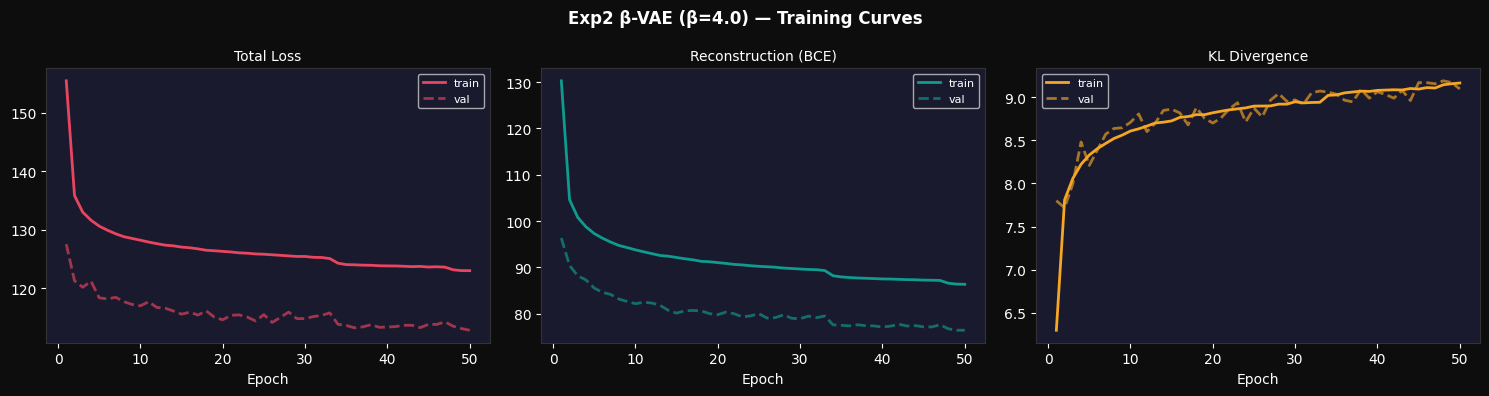

In [14]:
key_cfg = {
    "loss" : ("#e94560", "Total Loss"),
    "recon": ("#0f9b8e", "Reconstruction (BCE)"),
    "kl"   : ("#f5a623", "KL Divergence"),
    "C"    : ("#9b59b6", "Capacity C"),
    "equiv": ("#3498db", "Equivariance Loss"),
    "elbo" : ("#2ecc71", "val ELBO (β=1, fair)"),
}
active = [k for k in key_cfg if f"train_{k}" in history and len(history[f"train_{k}"]) > 0]
ep_x   = range(1, len(history["train_loss"])+1)
 
fig, axes = plt.subplots(1, len(active), figsize=(5*len(active), 4), facecolor="#0d0d0d")
if len(active) == 1: axes = [axes]
fig.suptitle(f"{EXP_NAME} — Training Curves", color="white", fontsize=12, fontweight="bold")
 
for ax, key in zip(axes, active):
    col, title = key_cfg[key]
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#333")
    ax.plot(ep_x, history[f"train_{key}"], color=col, lw=2, label="train")
    if f"val_{key}" in history and history[f"val_{key}"]:
        ax.plot(ep_x, history[f"val_{key}"], color=col, lw=2, ls="--", alpha=0.65, label="val")
    ax.set_title(title, color="white", fontsize=10)
    ax.set_xlabel("Epoch", color="white")
    ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "A_training_curves.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

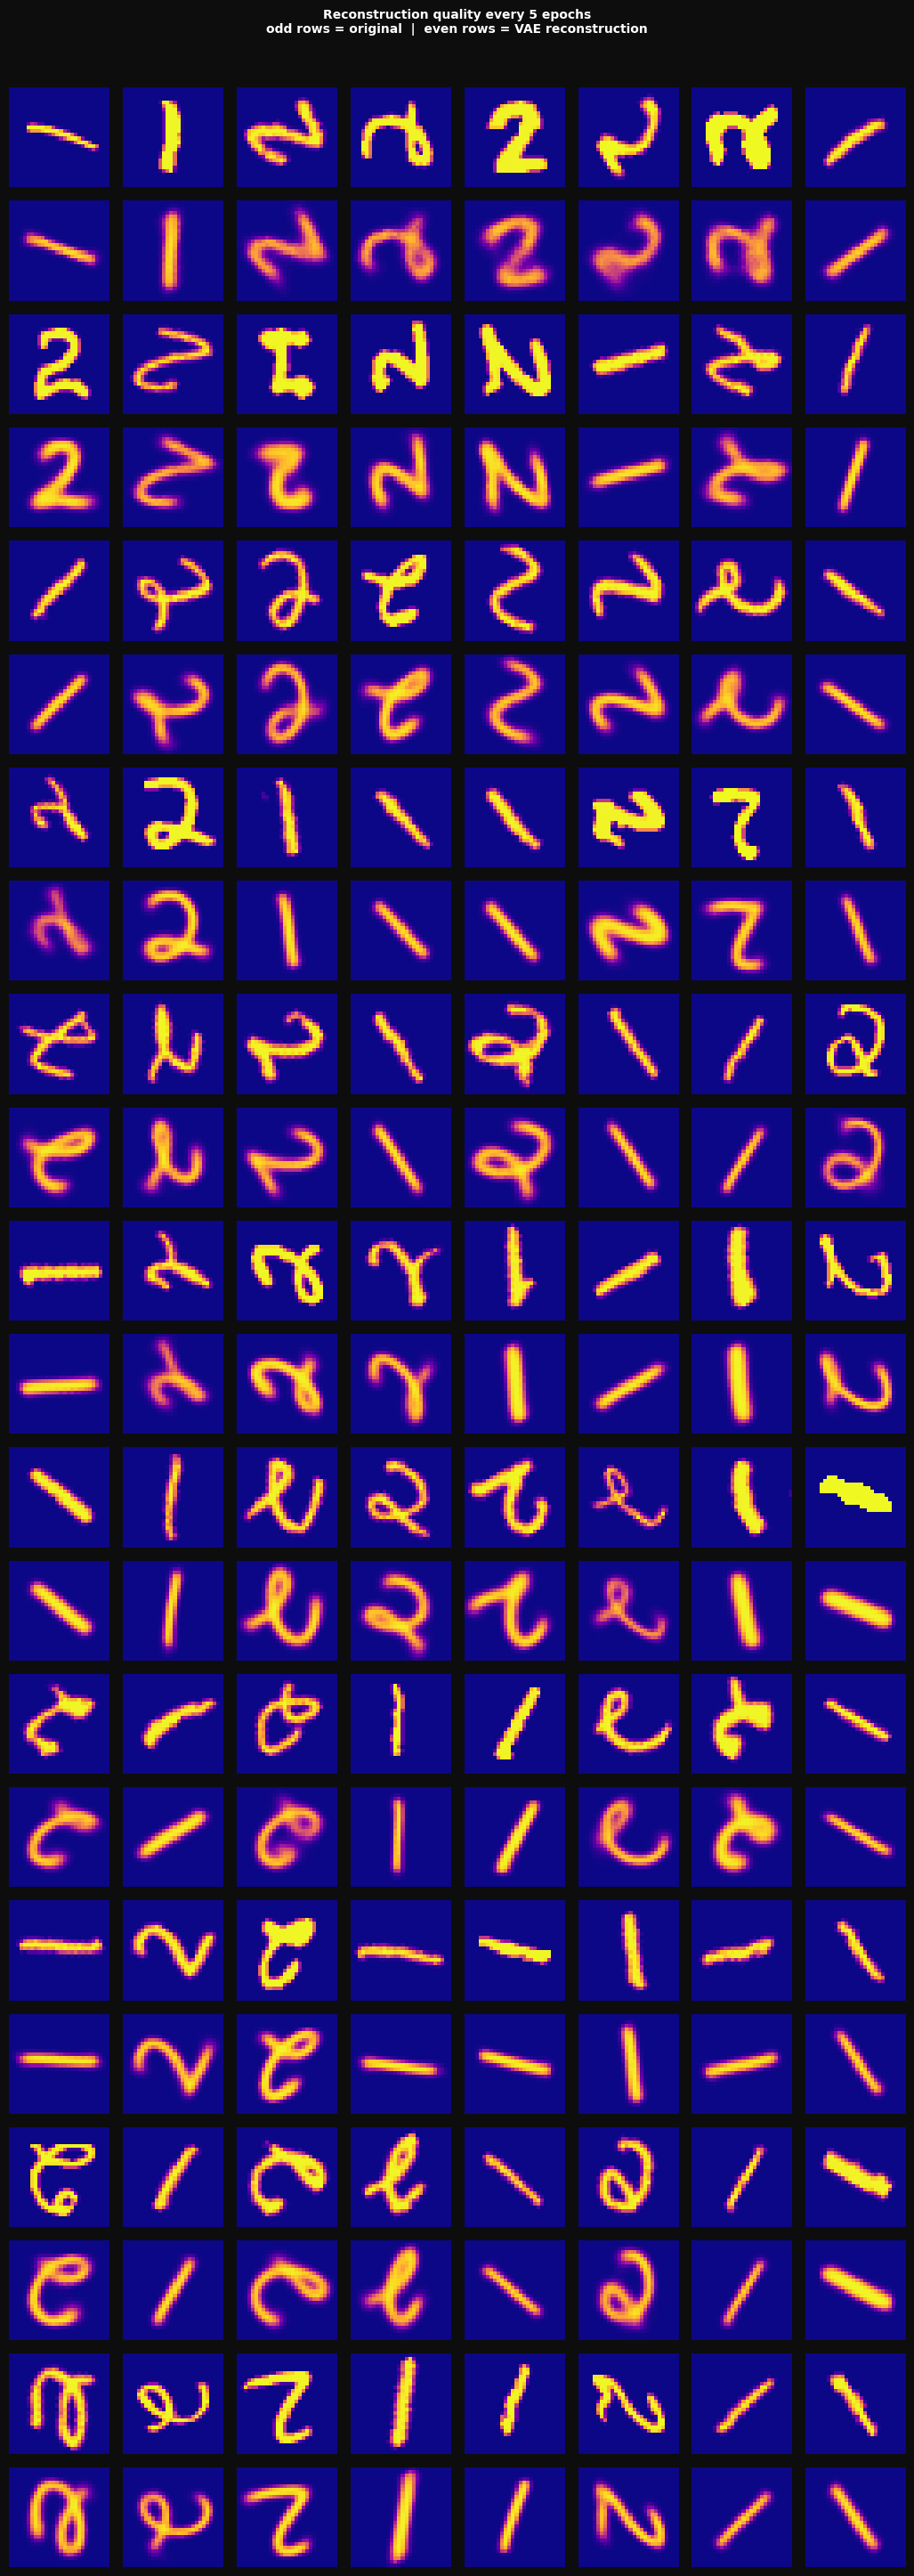

In [15]:
ep_list = sorted(snapshots.keys())
n_imgs  = 8
fig = plt.figure(figsize=(n_imgs*1.3, len(ep_list)*2.6), facecolor="#0d0d0d")
fig.suptitle("Reconstruction quality every 5 epochs\n"
             "odd rows = original  |  even rows = VAE reconstruction",
             color="white", fontsize=10, fontweight="bold", y=1.01)
 
for ri, ep in enumerate(ep_list):
    orig_np, recon_np = snapshots[ep]
    for c in range(n_imgs):
        ax = fig.add_subplot(len(ep_list)*2, n_imgs, ri*2*n_imgs + c + 1)
        ax.imshow(orig_np[c], cmap="plasma", vmin=0, vmax=1); ax.axis("off")
        if c == 0: ax.set_ylabel(f"Ep {ep}\norig", color="white", fontsize=7, rotation=0, labelpad=40)
        ax = fig.add_subplot(len(ep_list)*2, n_imgs, ri*2*n_imgs + n_imgs + c + 1)
        ax.imshow(recon_np[c], cmap="plasma", vmin=0, vmax=1); ax.axis("off")
        if c == 0: ax.set_ylabel("recon", color="#aaa", fontsize=7, rotation=0, labelpad=35)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "B_epoch_snapshots.png"),
            dpi=130, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

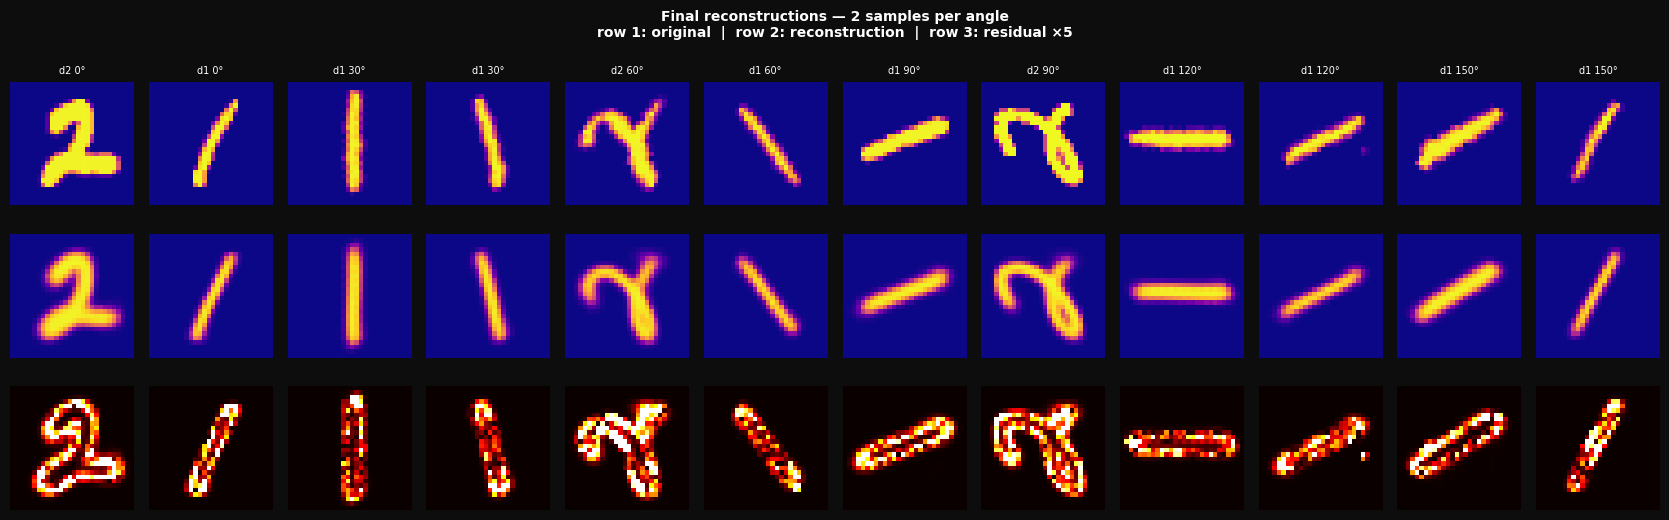

In [16]:
n = 12
best_model.eval()
rng_idx = []
for angle in ANGLES[:6]:
    mask  = (test_angs == angle).nonzero(as_tuple=True)[0]
    picks = mask[torch.randperm(len(mask))[:2]]
    rng_idx.extend(picks.tolist())
 
imgs_show = test_imgs[rng_idx].to(device)
with torch.no_grad():
    recon_show = best_model(imgs_show)[0].cpu()
 
fig, axes = plt.subplots(3, n, figsize=(n*1.4, 5.5), facecolor="#0d0d0d")
fig.suptitle("Final reconstructions — 2 samples per angle\n"
             "row 1: original  |  row 2: reconstruction  |  row 3: residual ×5",
             color="white", fontsize=10, fontweight="bold")
 
for c in range(n):
    orig  = imgs_show[c].cpu().squeeze().numpy()
    recon = recon_show[c].squeeze().numpy()
    resid = np.abs(orig - recon) * 5
    for r, (dat, cmap) in enumerate([(orig,"plasma"),(recon,"plasma"),(resid,"hot")]):
        ax = axes[r, c]
        ax.imshow(dat, cmap=cmap, vmin=0, vmax=1); ax.axis("off")
        if r == 0:
            ax.set_title(f"d{test_lbls[rng_idx[c]].item()} {test_angs[rng_idx[c]].item()}°",
                         color="white", fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "C_reconstructions.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

top-4 active dims : [6, 2, 13, 3]  (KL: [2.193000078201294, 1.781000018119812, 1.7100000381469727, 1.1089999675750732])


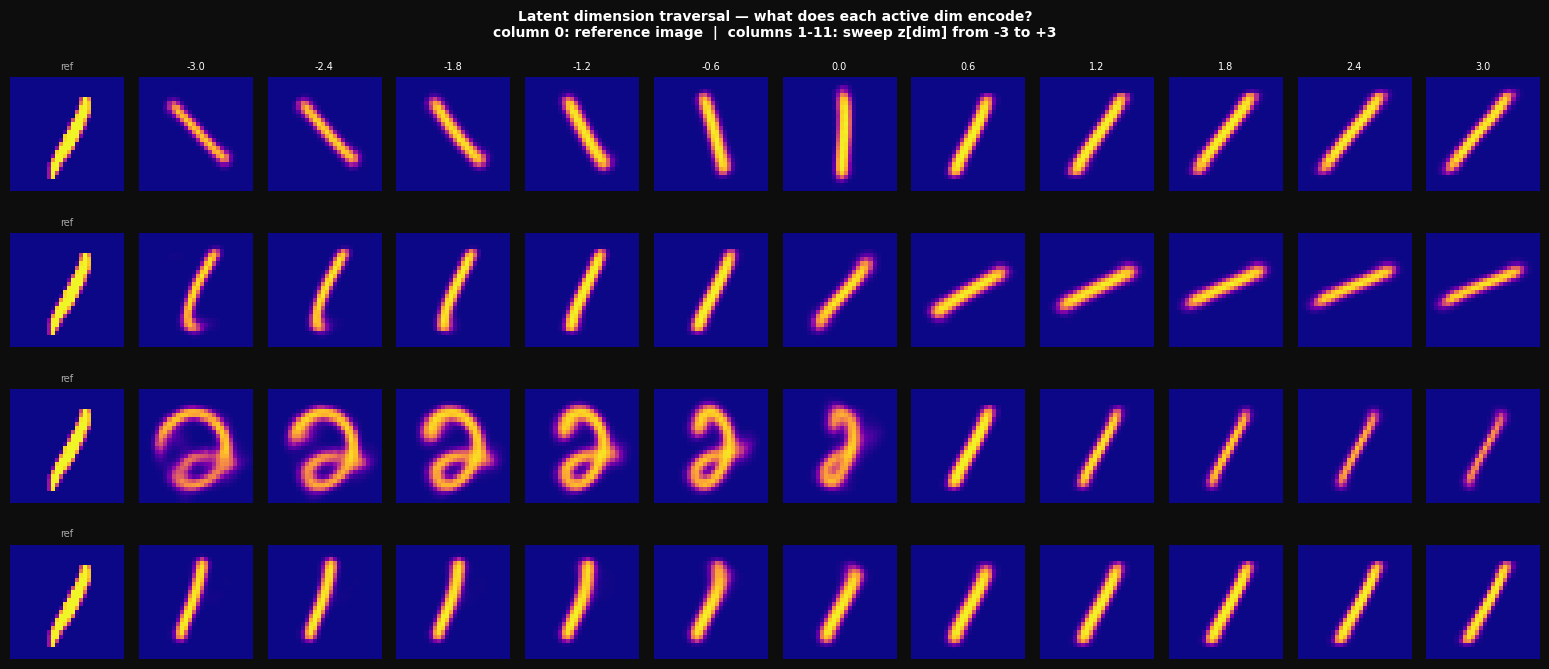

In [17]:
best_model.eval()
kl_acc = None; nb = 0
with torch.no_grad():
    for imgs, _, _ in test_loader:
        mu, lv = best_model.encoder(imgs.to(device, non_blocking=True))
        kl = -0.5 * (1 + lv - mu.pow(2) - lv.exp())
        kl_acc = kl.mean(0).cpu().numpy() if kl_acc is None else kl_acc + kl.mean(0).cpu().numpy()
        nb += 1
kl_per_dim = kl_acc / nb
top4 = kl_per_dim.argsort()[::-1][:4]
print(f"top-4 active dims : {top4.tolist()}  (KL: {kl_per_dim[top4].round(3).tolist()})")
 
# use a random test image as reference
ref_idx = torch.randperm(len(test_imgs))[0]
ref_img = test_imgs[ref_idx:ref_idx+1].to(device)
with torch.no_grad():
    ref_mu, _ = best_model.encoder(ref_img)
 
N_STEPS = 11
vals    = np.linspace(-3.0, 3.0, N_STEPS)
 
fig, axes = plt.subplots(4, N_STEPS+1, figsize=((N_STEPS+1)*1.3, 7), facecolor="#0d0d0d")
fig.suptitle("Latent dimension traversal — what does each active dim encode?\n"
             "column 0: reference image  |  columns 1-11: sweep z[dim] from -3 to +3",
             color="white", fontsize=10, fontweight="bold")
 
with torch.no_grad():
    for row, dim in enumerate(top4):
        axes[row,0].imshow(ref_img.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
        axes[row,0].axis("off")
        axes[row,0].set_title("ref", color="#aaa", fontsize=7)
        axes[row,0].set_ylabel(f"z[{int(dim)}]\nKL={kl_per_dim[dim]:.2f}",
                               color="white", fontsize=8, rotation=0, labelpad=44)
        for col, val in enumerate(vals):
            z = ref_mu.clone(); z[0, int(dim)] = val
            recon = best_model.decoder(z).cpu().squeeze().numpy()
            ax = axes[row, col+1]
            ax.imshow(recon, cmap="plasma", vmin=0, vmax=1); ax.axis("off")
            if row == 0: ax.set_title(f"{val:.1f}", color="white", fontsize=7)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "D_latent_traversal.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

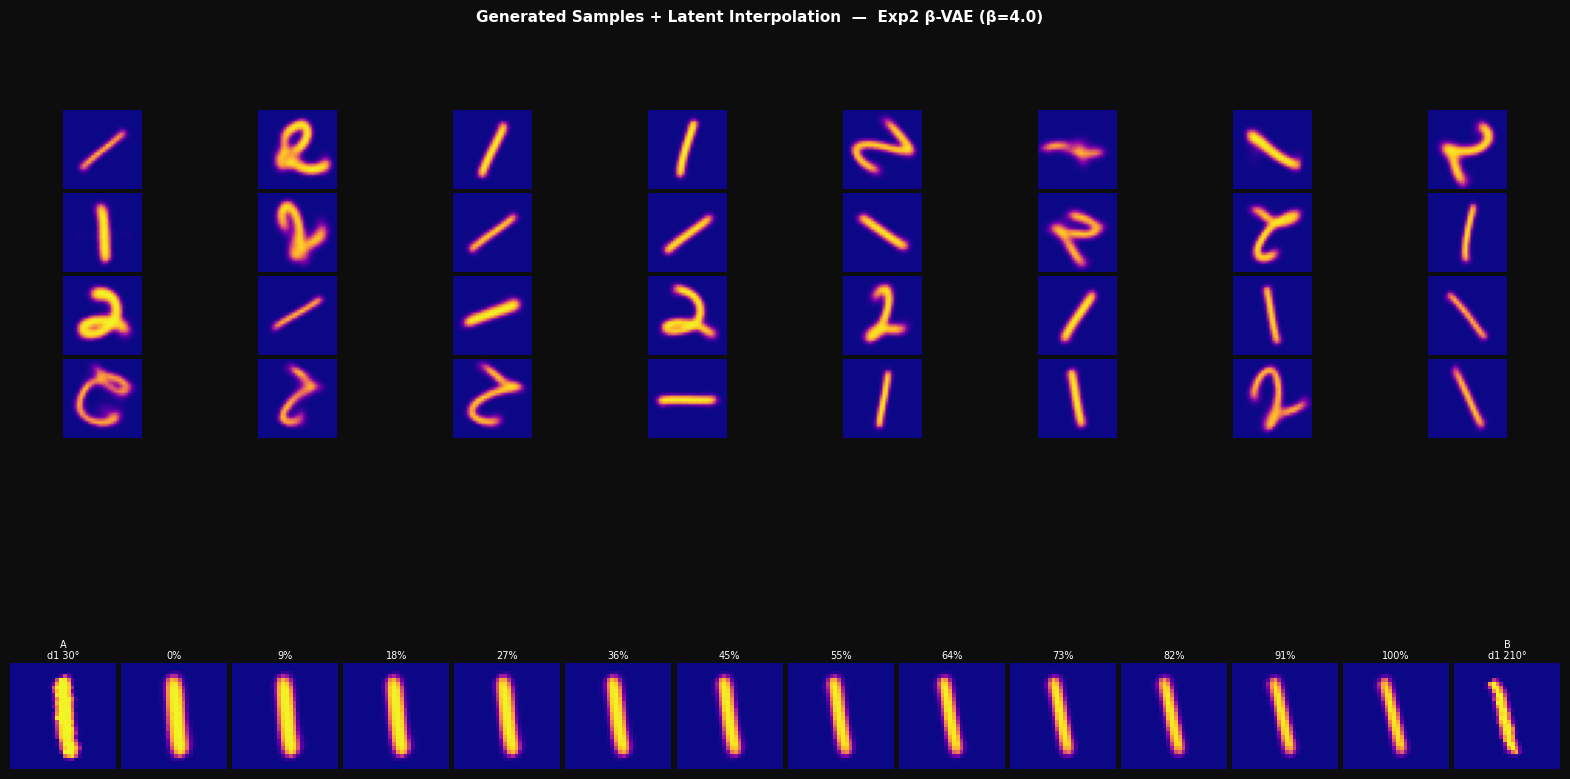

In [18]:
best_model.eval()
fig = plt.figure(figsize=(20, 10), facecolor="#0d0d0d")
fig.suptitle(f"Generated Samples + Latent Interpolation  —  {EXP_NAME}",
             color="white", fontsize=11, fontweight="bold")
gs_fig = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)
 
# generated samples
gs_top = gridspec.GridSpecFromSubplotSpec(4, 8, subplot_spec=gs_fig[0], hspace=0.05, wspace=0.05)
with torch.no_grad():
    z_rand = torch.randn(32, LATENT_DIM, device=device)
    gen    = best_model.decoder(z_rand).cpu()
for i in range(32):
    ax = fig.add_subplot(gs_top[i//8, i%8])
    ax.imshow(gen[i].squeeze().numpy(), cmap="plasma", vmin=0, vmax=1); ax.axis("off")
    if i == 0: ax.set_ylabel("z~N(0,I)\ngenerated", color="white", fontsize=8, rotation=0, labelpad=55)
 
# interpolation
N_INT = 12
ra = torch.randperm(len(test_imgs))[0]; rb = torch.randperm(len(test_imgs))[0]
ia = test_imgs[ra:ra+1].to(device);    ib = test_imgs[rb:rb+1].to(device)
with torch.no_grad():
    za, _ = best_model.encoder(ia); zb, _ = best_model.encoder(ib)
    interp = [best_model.decoder((1-a)*za + a*zb).cpu() for a in np.linspace(0,1,N_INT)]
 
la = test_lbls[ra].item(); aa = test_angs[ra].item()
lb = test_lbls[rb].item(); ab = test_angs[rb].item()
gs_bot = gridspec.GridSpecFromSubplotSpec(1, N_INT+2, subplot_spec=gs_fig[1], hspace=0.05, wspace=0.05)
all_int = [ia.cpu()] + interp + [ib.cpu()]
int_lbl = ([f"A\nd{la} {aa}°"] + [f"{a:.0%}" for a in np.linspace(0,1,N_INT)] + [f"B\nd{lb} {ab}°"])
for i, (img, lbl) in enumerate(zip(all_int, int_lbl)):
    ax = fig.add_subplot(gs_bot[0, i])
    ax.imshow(img.squeeze().numpy(), cmap="plasma", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(lbl, color="white", fontsize=7, pad=3)
    if i == 0: ax.set_ylabel("interpolation", color="white", fontsize=8, rotation=0, labelpad=52)
 
plt.savefig(os.path.join(OUT_DIR, "F_generated_interp.png"),
            dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [19]:
print("=" * 60)
print(f"  RESULTS  —  {EXP_NAME}")
print("=" * 60)
print()
print("  PRIMARY EVALUATION METRICS (symmetry discovery)")
print(f"    RIE  (Rotation Invariance Error)  : {rie:.4f}  ← lower = better")
print(f"    LP-AUC (Linear Probe AUC)         : {lp_auc:.4f}  ← higher = better")
print(f"    OCS  (Orbit Circularity Score)     : {ocs:.4f}  ← characterises geometry")
print()
print("  TRAINING DIAGNOSTICS (do not compare across experiments directly)")
print(f"    best val ELBO (β=1)  : {min(history.get('val_elbo', history['val_loss'])):.2f}")
print(f"    final val recon      : {history['val_recon'][-1]:.2f}")
print(f"    final val KL         : {history['val_kl'][-1]:.4f}")
print()
# verdict
if rie < 1.0 and lp_auc > 0.90:
    verdict = "✅  symmetry learned AND class information preserved"
elif rie < 1.0 and lp_auc < 0.80:
    verdict = "⚠️   rotation-invariant BUT class information lost — model may have collapsed"
elif rie > 2.0 and lp_auc > 0.90:
    verdict = "❌  class info ok BUT symmetry not learned — check lambda_inv or training"
else:
    verdict = "🔄  partial — continue training or adjust hyperparameters"
print(f"  VERDICT : {verdict}")
print()
print("=" * 60)
print(f"  outputs → {OUT_DIR}/")
for fn in sorted(os.listdir(OUT_DIR)):
    kb = os.path.getsize(os.path.join(OUT_DIR, fn)) // 1024
    print(f"    {fn:<42} {kb:>5} KB")

  RESULTS  —  Exp2 β-VAE (β=4.0)

  PRIMARY EVALUATION METRICS (symmetry discovery)
    RIE  (Rotation Invariance Error)  : 2.9607  ← lower = better
    LP-AUC (Linear Probe AUC)         : 0.9984  ← higher = better
    OCS  (Orbit Circularity Score)     : 0.8398  ← characterises geometry

  TRAINING DIAGNOSTICS (do not compare across experiments directly)
    best val ELBO (β=1)  : 85.56
    final val recon      : 76.47
    final val KL         : 9.0940

  VERDICT : ❌  class info ok BUT symmetry not learned — check lambda_inv or training

  outputs → /kaggle/working/exp2_beta_vae/
    00_data_preview.png                           35 KB
    A_training_curves.png                         95 KB
    B_epoch_snapshots.png                        231 KB
    C_reconstructions.png                         64 KB
    D_latent_traversal.png                        83 KB
    E_eval_metrics.png                           699 KB
    F_generated_interp.png                        85 KB
    best_model.pt   